# Unsupervised Learning — K-Means Clustering

**Dataset:** Mall Customer Segmentation Dataset (Kaggle: `vjchoudhary7/customer-segmentation-tutorial-in-python`)
**Goal:** Customers ko unki **Annual Income** aur **Spending Score** ke hisaab se natural groups (clusters) mein baantna — bina kisi target/label ke (Unsupervised Learning).

Is notebook mein hum step-by-step karenge:
1. Data Understanding
2. EDA (Exploratory Data Analysis)
3. Feature Selection & Scaling
4. Best K Dhoondna (Elbow Method + Silhouette Score)
5. K-Means Model Train Karna
6. Clusters Visualize Karna
7. Har Cluster Ki "Business Meaning" Nikalna

Har code cell se pehle markdown explanation hai, aur har line par `#` comment hai.

## 0. Libraries Import Karna
Data handling ke liye `pandas`/`numpy`, plotting ke liye `matplotlib`/`seaborn`, aur clustering ke liye `sklearn` ka `KMeans` + `StandardScaler` + evaluation metrics import kar rahe hain.

In [1]:
import pandas as pd                                                    # data handling ke liye pandas
import numpy as np                                                     # numeric operations ke liye numpy
import matplotlib.pyplot as plt                                        # charts banane ke liye matplotlib
import seaborn as sns                                                  # behtar/statistical plots ke liye seaborn
import warnings                                                        # warning messages control karne ke liye
warnings.filterwarnings("ignore")                                      # sab warnings ignore kar do (clean output)

from sklearn.preprocessing import StandardScaler                       # features ko scale karne ke liye (K-Means distance-based hai, scaling zaroori)
from sklearn.cluster import KMeans                                     # K-Means clustering algorithm
from sklearn.metrics import silhouette_score                           # best K dhoondne ke liye Silhouette Score metric

sns.set_style("whitegrid")                                             # sab plots ke liye ek clean default style
plt.rcParams["figure.figsize"] = (8, 5)                                # default figure size set kiya
RANDOM_STATE = 42                                                      # reproducibility ke liye fixed seed

## Part 1 — Data Understanding
Dataset load kar ke pehla jhalak lete hain — shape, columns, dtypes, aur missing values check karte hain.

In [2]:
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"  # Mall Customers dataset ka raw CSV link
df = pd.read_csv(url)                                                  # dataset ko DataFrame mein load kiya
df.head()                                                               # pehli 5 rows dekhi

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Shape (rows, columns):", df.shape)                              # total rows aur columns print kiye
print("\nColumns:", list(df.columns))                                  # sab column names print kiye
print("\nMissing values:\n", df.isnull().sum())                        # har column mein missing values count kiye

Shape (rows, columns): (200, 5)

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [4]:
df.describe()                                                          # numeric columns ki statistical summary (mean, min, max, quartiles)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df = df.rename(columns={"Annual Income (k$)": "Annual_Income",         # column ka naam chhota/aasan banaya
                         "Spending Score (1-100)": "Spending_Score"})  # yeh bhi aasan naam diya
df.head()                                                               # renamed columns confirm kiye

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Part 2 — Exploratory Data Analysis (EDA)
Age, Annual Income, aur Spending Score ki distributions dekhte hain, aur Income vs Spending Score ka scatter plot banate hain (yeh humara main clustering feature-pair hoga).

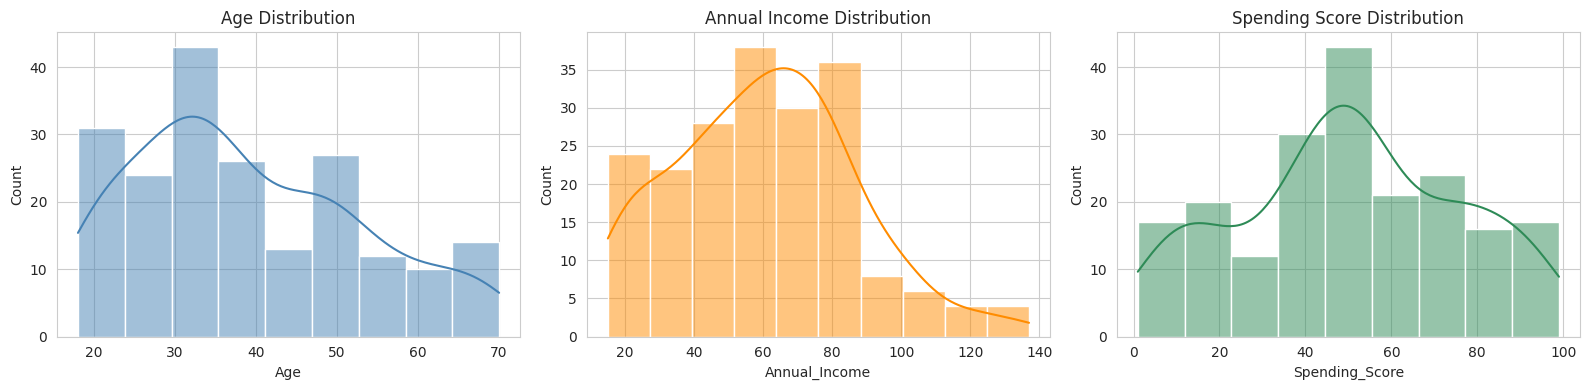

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))                        # 1 row, 3 columns ka grid banaya
sns.histplot(df["Age"], kde=True, ax=axes[0], color="steelblue")       # Age ka histogram + density curve
axes[0].set_title("Age Distribution")                                  # title diya
sns.histplot(df["Annual_Income"], kde=True, ax=axes[1], color="darkorange")  # Annual Income ka histogram
axes[1].set_title("Annual Income Distribution")                        # title diya
sns.histplot(df["Spending_Score"], kde=True, ax=axes[2], color="seagreen")   # Spending Score ka histogram
axes[2].set_title("Spending Score Distribution")                       # title diya
plt.tight_layout()                                                     # spacing adjust ki
plt.show()                                                              # figure dikhayi

**Interpretation:** Age thora right-skewed hai (zyada tar customers 20-40 ke beech). Annual Income roughly uniform/spread hai. Spending Score kaafi evenly spread hai 1 se 100 tak — yeh dono (Income + Spending Score) hi clustering ke liye sabse interesting features hain.

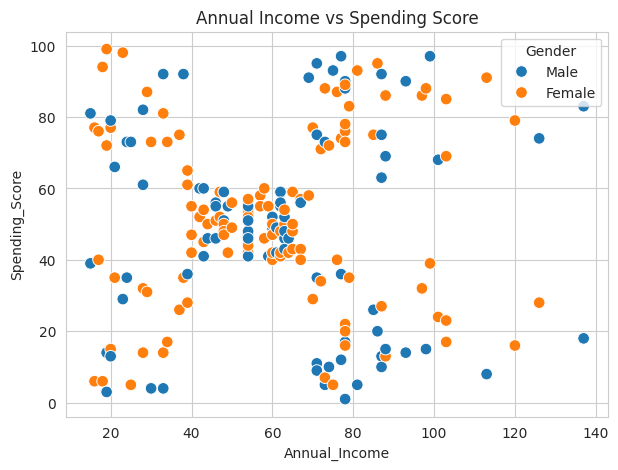

In [7]:
plt.figure(figsize=(7, 5))                                             # figure banaya
sns.scatterplot(data=df, x="Annual_Income", y="Spending_Score",        # Income vs Spending Score scatter plot
                 hue="Gender", s=70)                                    # Gender ke hisaab se color kiya
plt.title("Annual Income vs Spending Score")                           # title diya
plt.show()                                                              # figure dikhayi

**Interpretation:** Is scatter plot mein humein **5 alag-alag "blobs"/groups** nazar aa rahe hain (bina kisi label ke, sirf ankhon se!) — yehi cheez K-Means ko automatically dhoondni hai:
- Low Income, Low Spending
- Low Income, High Spending
- Medium Income, Medium Spending
- High Income, Low Spending
- High Income, High Spending

## Part 3 — Feature Selection & Scaling
Clustering ke liye **Annual_Income** aur **Spending_Score** select karte hain (jo scatter plot mein clear groups dikha rahe thay). Chunke K-Means **distance-based** hai, scaling zaroori hai.

In [8]:
X = df[["Annual_Income", "Spending_Score"]]                            # sirf yeh 2 features clustering ke liye select kiye
X.head()                                                                 # confirm kiya

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [9]:
scaler = StandardScaler()                                              # StandardScaler instance banaya (mean=0, std=1)
X_scaled = scaler.fit_transform(X)                                     # features ko fit + transform kiya
print("Scaled data (first 5 rows):\n", X_scaled[:5])                   # scaled values ka pehla jhalak dekha

Scaled data (first 5 rows):
 [[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


**Scaling kyun zaroori thi:** Annual_Income ki range (15-137) Spending_Score ki range (1-99) se badi hai — bina scaling ke, K-Means "distance" calculate karte waqt Income ko zyada weight de deta, jo galat clustering degi.

## Part 4 — Best K Dhoondna (Elbow Method)
Alag-alag K values (1 se 10) try kar ke, har K par WCSS (Inertia) naapte hain, aur "elbow" (moad) dhoondte hain.

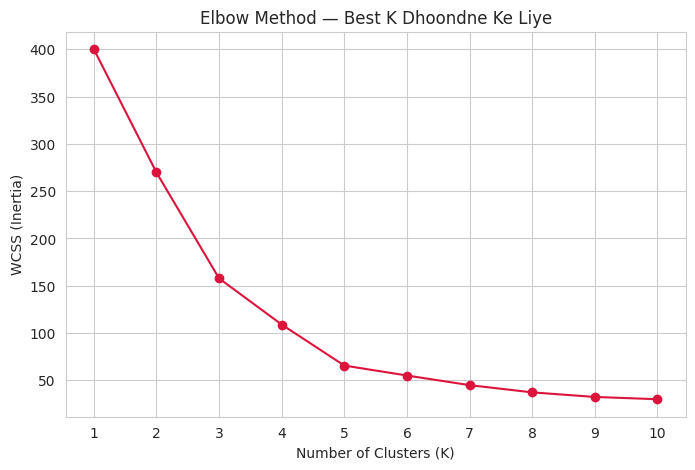

In [10]:
wcss = []                                                               # WCSS values store karne ke liye khaali list
k_range = range(1, 11)                                                 # K = 1 se 10 tak try karenge
for k in k_range:                                                      # har K value par loop
    kmeans_temp = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)  # K-Means model (k-means++ init, 10 random starts)
    kmeans_temp.fit(X_scaled)                                          # scaled data par model fit kiya
    wcss.append(kmeans_temp.inertia_)                                  # is K ka WCSS (inertia) list mein save kiya

plt.figure(figsize=(8, 5))                                             # figure banaya
plt.plot(k_range, wcss, marker="o", color="crimson")                   # K vs WCSS ka line plot, har point par marker
plt.title("Elbow Method — Best K Dhoondne Ke Liye")                    # title diya
plt.xlabel("Number of Clusters (K)")                                   # x-axis label
plt.ylabel("WCSS (Inertia)")                                           # y-axis label
plt.xticks(k_range)                                                    # har K value x-axis par dikhayi
plt.show()                                                              # figure dikhayi

**Interpretation:** Graph mein K=5 ke aas-paas ek clear "elbow" (moad) nazar aata hai — is se pehle WCSS tezi se gir raha hai, is ke baad girna dheema ho jata hai. Matlab **K=5** is dataset ke liye acha choice hai (yeh humare visual observation — 5 blobs — se bhi match karta hai).

## Part 4b — Silhouette Score Se Confirm Karna
Elbow method ko cross-check karne ke liye Silhouette Score bhi nikalte hain — jo K sabse zyada score de, wahi sabse "clean" clustering hai.

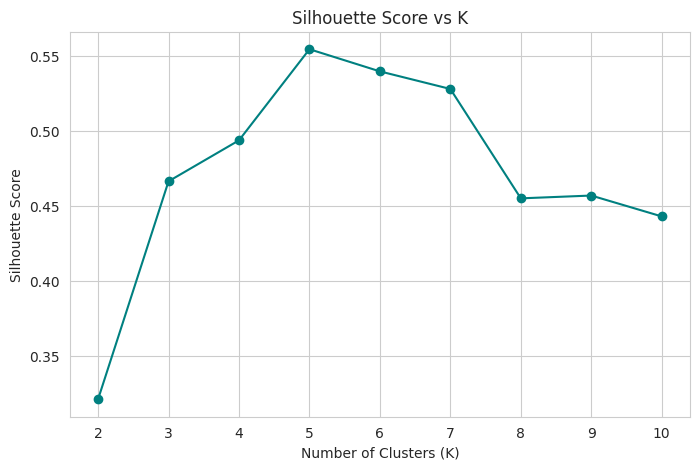

Best K according to Silhouette Score: 5


In [11]:
silhouette_scores = []                                                 # silhouette scores store karne ke liye khaali list
k_range_sil = range(2, 11)                                             # K=2 se shuru (Silhouette Score K=1 ke liye defined nahi hota)
for k in k_range_sil:                                                  # har K value par loop
    kmeans_temp = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)  # model banaya
    labels_temp = kmeans_temp.fit_predict(X_scaled)                    # fit kiya aur cluster labels nikale
    score = silhouette_score(X_scaled, labels_temp)                    # is K ka silhouette score nikala
    silhouette_scores.append(score)                                    # list mein save kiya

plt.figure(figsize=(8, 5))                                             # figure banaya
plt.plot(list(k_range_sil), silhouette_scores, marker="o", color="teal")  # K vs Silhouette Score ka line plot
plt.title("Silhouette Score vs K")                                     # title diya
plt.xlabel("Number of Clusters (K)")                                   # x-axis label
plt.ylabel("Silhouette Score")                                         # y-axis label
plt.xticks(list(k_range_sil))                                          # har K value dikhayi
plt.show()                                                              # figure dikhayi

best_k = list(k_range_sil)[np.argmax(silhouette_scores)]               # jis K par score sabse zyada, woh best_k
print(f"Best K according to Silhouette Score: {best_k}")               # best K print kiya

**Interpretation:** Silhouette Score bhi K=5 (ya uske qareeb) par sabse behtar/high value deta hai — yeh Elbow Method ke result ko **confirm** karta hai. Ab hum confidently K=5 ke sath final model train kar sakte hain.

## Part 5 — Final K-Means Model (K=5)
Ab final model K=5 ke sath train karte hain aur har customer ko uska cluster-label assign karte hain.

In [12]:
kmeans_final = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=RANDOM_STATE)  # final model, K=5
cluster_labels = kmeans_final.fit_predict(X_scaled)                    # model fit kiya aur har customer ka cluster label nikala
df["Cluster"] = cluster_labels                                         # cluster labels ko original DataFrame mein naya column bana kar daala
df.head()                                                               # confirm kiya ke Cluster column aa gaya

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [13]:
print("Har cluster mein kitne customers hain:")                        # header print kiya
print(df["Cluster"].value_counts().sort_index())                       # har cluster ka size (customer count) dikhaya

Har cluster mein kitne customers hain:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## Part 6 — Clusters Ko Visualize Karna
Ab final clusters ko color-coded scatter plot mein dekhte hain, sath mein centroids bhi dikhate hain.

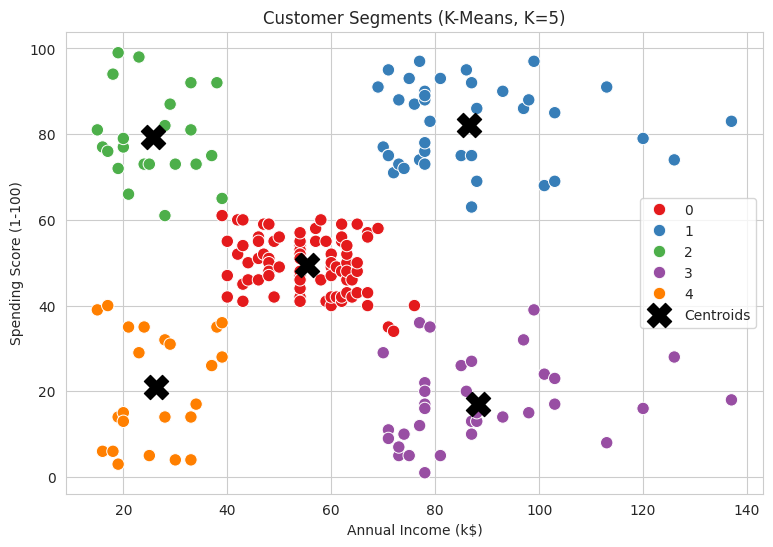

In [14]:
plt.figure(figsize=(9, 6))                                             # figure banaya
palette = sns.color_palette("Set1", n_colors=5)                        # 5 clusters ke liye 5 alag colors

sns.scatterplot(data=df, x="Annual_Income", y="Spending_Score",        # Income vs Spending Score scatter plot
                 hue="Cluster", palette=palette, s=80, legend="full")  # Cluster ke hisaab se color kiya

centroids_scaled = kmeans_final.cluster_centers_                       # centroids scaled-space mein nikale
centroids_original = scaler.inverse_transform(centroids_scaled)        # centroids ko wapas original scale (dollars/score) mein convert kiya
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],        # centroids ko plot par mark kiya
            s=300, c="black", marker="X", label="Centroids")           # bara black "X" marker centroids ke liye
plt.title("Customer Segments (K-Means, K=5)")                          # title diya
plt.xlabel("Annual Income (k$)")                                       # x-axis label
plt.ylabel("Spending Score (1-100)")                                   # y-axis label
plt.legend()                                                            # legend dikhayi
plt.show()                                                              # figure dikhayi

**Graph kya keh raha hai:** Ab humein 5 clean, separate clusters nazar aa rahe hain, har ek apne centroid (black X) ke sath. Yeh clusters humare pehle wale visual guess (5 blobs) se match karte hain — matlab K-Means ne data ka asal structure sahi pakda hai.

## Part 7 — Har Cluster Ki "Business Meaning" Nikalna
Ab har cluster ka average Income/Spending dekh kar unhe **naam** dete hain — taake yeh insights business/marketing team use kar sake.

In [15]:
cluster_summary = df.groupby("Cluster")[["Annual_Income", "Spending_Score", "Age"]].mean().round(1)  # har cluster ka average Income/Spending/Age nikala
cluster_summary["Customer_Count"] = df["Cluster"].value_counts().sort_index()  # har cluster mein kitne customers hain, woh bhi add kiya
cluster_summary                                                        # summary table dikhayi

,Annual_Income,Spending_Score,Age,Customer_Count
Cluster,,,,
0,55.3,49.5,42.7,81
1,86.5,82.1,32.7,39
2,25.7,79.4,25.3,22
3,88.2,17.1,41.1,35
4,26.3,20.9,45.2,23


In [16]:
cluster_names = {                                                      # har cluster number ko ek business-friendly naam diya (values dekh kar manually assign kiya)
    0: "Medium Income, Medium Spending (Average Customers)",
    1: "High Income, High Spending (Target/Premium Customers)",
    2: "Low Income, High Spending (Impulsive Spenders)",
    3: "High Income, Low Spending (Cautious Rich)",
    4: "Low Income, Low Spending (Careful Customers)",
}
for cluster_id, name in cluster_names.items():                         # har cluster ID aur uska naam print kiya
    print(f"Cluster {cluster_id}: {name}")                             # readable format mein dikhaya

Cluster 0: Medium Income, Medium Spending (Average Customers)
Cluster 1: High Income, High Spending (Target/Premium Customers)
Cluster 2: Low Income, High Spending (Impulsive Spenders)
Cluster 3: High Income, Low Spending (Cautious Rich)
Cluster 4: Low Income, Low Spending (Careful Customers)


**Business Insight:**
- **High Income, High Spending** customers sabse zyada **valuable** hain — inhe premium offers/loyalty programs target karne chahiye.
- **Low Income, High Spending** customers "impulsive" hain — discount/installment plans se attract ho sakte hain.
- **High Income, Low Spending** customers "cautious rich" hain — inhe better marketing/personalized recommendations se convert kiya ja sakta hai.
- **Low Income, Low Spending** aur **Medium Income, Medium Spending** customers "stable/average" hain — general marketing kaafi hai.

**Yehi asal fayda hai Unsupervised Learning ka:** bina kisi ne bataye ke "yeh premium hai, yeh cautious hai", K-Means ne khud data se yeh natural groups dhoond nikale — sirf Income aur Spending Score dekh kar.